In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits

# load the RGB values from file
from matplotlib.colors import ListedColormap

nside = 2048 #resolution of the map in pixels

#importing useful libraries

In [2]:
hdul = fits.open("WPR1_CMB_muK.fits")
#print(hdul[1].columns)

T_nested = hdul[1].data["UNKNOWN1"].reshape(-1)     # or: .flatten() to reshape the data to a 1D array

# convert from NESTED to RING ordering
T_ring = hp.reorder(T_nested, n2r=True)

# print(cmb_data.shape)         # should be (50331648,)
# print(hp.get_nside(cmb_data)) # should be 2048

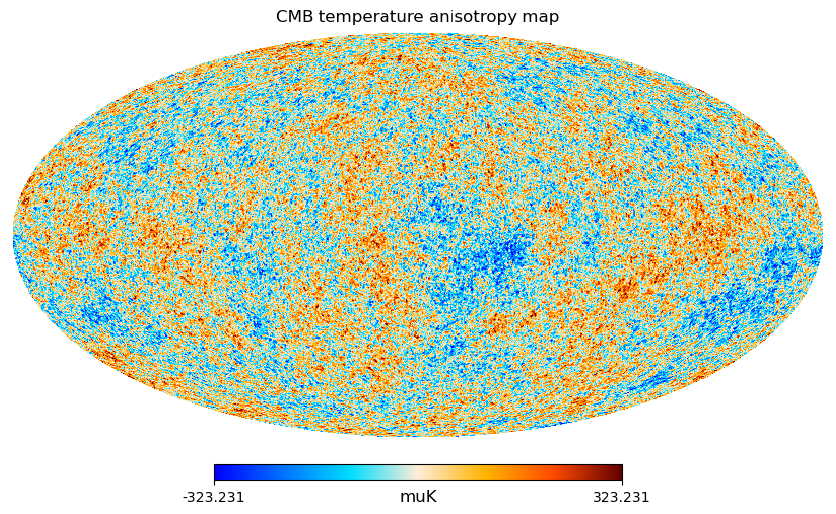

In [3]:
# hp.mollview(cmb_data * 1e6, title="Planck SMICA CMB Map", unit="uK_CMB", min=-300, max=300)
# plt.show()

# hp.mollview(cmb_data, title="Planck SMICA CMB Map", unit="K_CMB", min=-3e-4, max=3e-4)
# plt.show()

cmb_data = np.array(T_ring, dtype=np.float64)


# custom colormap
colors = np.loadtxt("color_map.txt") / 255.0
cmap = ListedColormap(colors)
cmap.set_bad("white")
cmap.set_under("white")


# remove monopole/dipole
cmb_clean, monopole, dipole = hp.remove_dipole(cmb_data, fitval=True)

cmb_clean = np.where(cmb_clean == hp.UNSEEN, np.nan, cmb_clean)

# choose visualization range
sigma = np.nanstd(cmb_clean)

hp.mollview(
    cmb_clean,
    cmap=cmap,
    min=-3*sigma,
    max=3*sigma,
    title="CMB temperature anisotropy map",
    bgcolor="white",
    badcolor="white",
    unit="muK"
)

In [4]:
nside = hp.get_nside(cmb_clean)
l_max = 3000

alm = hp.map2alm(cmb_clean, lmax=l_max, pol=False)
alm

array([-6.14669897e-07+0.j        , -7.46698141e-06+0.j        ,
        1.12320692e+01+0.j        , ...,  1.13900909e-03-0.00724139j,
        7.94870451e-03-0.00068109j,  1.58970119e-03+0.01619552j],
      shape=(4504501,))

In [5]:
cl = hp.alm2cl(alm)      # angular power spectrum C_l
#T_rec = hp.alm2map(alm, nside=nside, lmax=lmax, verbose=False)  # reconstruct map
cl

array([3.77819082e-13, 1.85918228e-11, 1.88622096e+02, ...,
       3.05731078e-04, 2.99991722e-04, 3.12778864e-04], shape=(3001,))

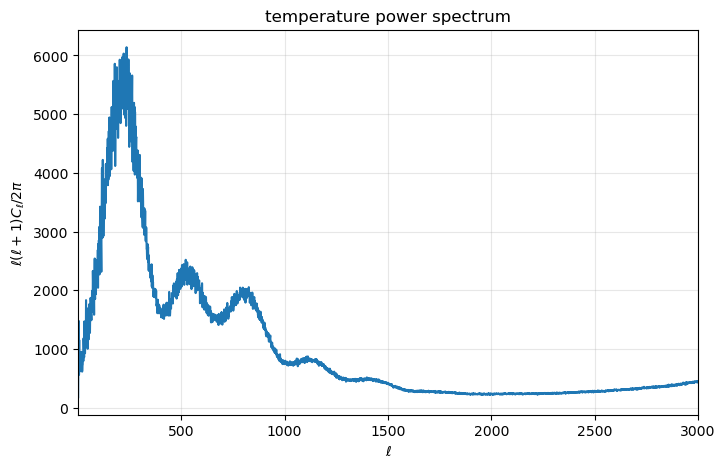

In [6]:
ell = np.arange(len(cl))

plt.figure(figsize=(8,5))
plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl[2:] / (2*np.pi))
plt.xlabel(r"$\ell$")
plt.xlim(2, 3000)
plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
# plt.xscale('log')
# plt.yscale('log')
# Setting X and Y axis data points
x = [ell]
y = [cl]

# plotting the points on the graph
# plt.plot(x,y)
plt.title("temperature power spectrum")
plt.grid(alpha=0.3)
plt.show()


(3001, 2)


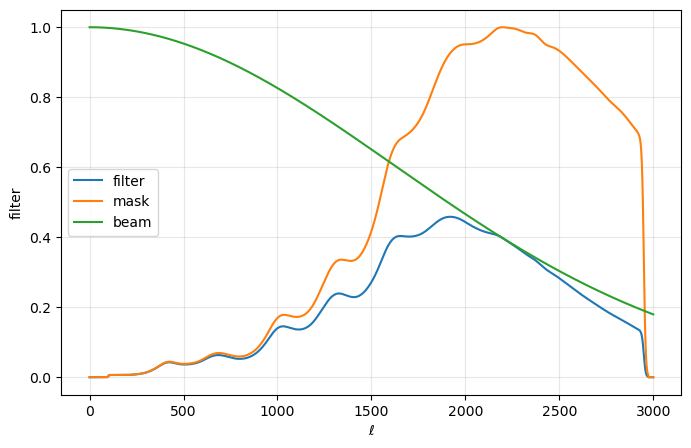

In [7]:
mask = np.loadtxt("filter.txt") #2D array that contains ell in first column and mask values in second column
print(mask.shape)

FWMN = 5.0  # Full Width at Half Maximum of the beam in arcminutes
FWHM = FWMN * np.pi / (180 * 60)  # convert FWHM from arcminutes to radians

ell = np.arange(3001)
beam = np.exp(-0.5 * ell * (ell + 1) * (FWHM / np.sqrt((8 * np.log(2))))**2)

filter = mask[:, 1] * beam

plt.figure(figsize=(8,5))
plt.plot(ell, filter, label="filter")
plt.plot(ell, mask[:, 1], label="mask")
plt.plot(ell, beam, label="beam")
plt.xlabel(r"$\ell$")
plt.ylabel("filter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
alm_filtered = hp.almxfl(alm, filter)
print(alm_filtered.shape)



(4504501,)


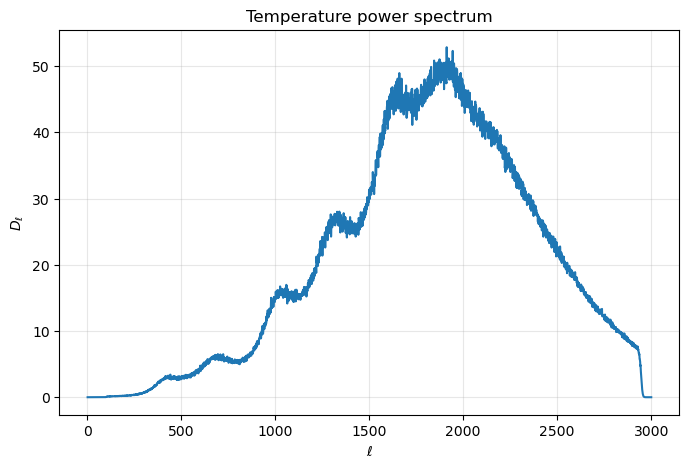

In [9]:
cl = hp.alm2cl(alm_filtered)    # angular power spectrum C_l of the filtered alm coefficients
ell = np.arange(len(cl))

plt.figure(figsize=(8,5))
plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl[2:] / (2*np.pi), label='Filtered')
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell$")
plt.title("Temperature power spectrum")
plt.grid(alpha=0.3)
plt.show()



In [ ]:
masked_temp = hp.alm2map(alm_filtered, nside=nside, lmax=l_max)  # reconstruct map from filtered alm coefficients

# # custom colormap
colors = np.loadtxt("color_map.txt") / 255.0
cmap = ListedColormap(colors)
cmap.set_bad("white")
cmap.set_under("white")


# remove monopole/dipole
cmb_clean = hp.remove_dipole(masked_temp)
cmb_clean = np.where(cmb_clean == hp.UNSEEN, np.nan, cmb_clean)

# choose visualization range
sigma = np.std(cmb_clean)

hp.mollview(
    cmb_clean,
    cmap=cmap,
    min=-3*sigma,
    max=3*sigma,
    title="filtered CMB map",
    bgcolor="white",
    badcolor="white",
    unit="muK"
)

plt.show()


In [ ]:
# hdul_gal = fits.open("../galaxy_samples/1_delta.fits")

# # hdul.info()
# # print(hdul[0].header)   # primary header cards
# # print(hdul[1].header)   # table header cards

# gal = hdul_gal[1].data[hdul_gal[1].header["TTYPE1"]]

# print(hdul_gal[1].header["ORDERING"])


# # print(temperature_map)
# # print(type(temperature_map))

In [ ]:
# gal_flat = gal.flatten()
# print(gal.shape)

# gal_distr = hp.remove_dipole(gal_flat)

# # gal_distr = hp.reorder(gal_flat, n2r=True)

# l_max = 3000

# alm_gal = hp.map2alm(gal_distr, lmax=l_max, pol=False)

In [ ]:
# hp.mollview(gal_distr, title="galaxy distribution", unit="muK", cmap="viridis", min=-2, max=2)
# plt.show()

In [ ]:
# cl_gal = hp.alm2cl(alm_gal)    # angular power spectrum C_l of the galaxy distribution
# ell = np.arange(len(cl_gal))

In [ ]:
# plt.figure(figsize=(8,5))
# plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl_gal[2:] / (2*np.pi))
# plt.xlabel(r"$\ell$")
# plt.xlim(2, 3000)
# plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
# # plt.xscale('log')
# # plt.yscale('log')
# plt.title("galaxy distribution power spectrum")
# plt.grid(alpha=0.3)
# plt.show()

In [ ]:
# hdul_mask_1 = fits.open("../masks/dat_klm.fits")
# hdul_mask_2 = fits.open("../masks/mf_klm.fits")

In [ ]:
# delta_g_1 = hdul_mask_1[1].data

# real = delta_g_1["real"]
# imag = delta_g_1["imag"]

# alm_delta_1 = real + 1j * imag
# # alm_delta_1

# alm_final = hp.almxfl(alm_gal, alm_delta_1)



In [ ]:
# cl_delta_1 = hp.alm2cl(alm_final)    # angular power spectrum C_l of the final alm coefficients

# ell_delta_1 = np.arange(len(cl_delta_1))

# plt.figure(figsize=(8,5))

# plt.plot(
#     ell_delta_1[2:],
#     ell_delta_1[2:] * (ell_delta_1[2:] + 1) * cl_delta_1[2:] / (2*np.pi)
# )

# # plt.xscale("log")
# # plt.yscale("log")

# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")

# plt.title("angular power spectrum")

# plt.grid(alpha=0.3)

# plt.show()

In [ ]:
# coeff = hdul[1].data

# print(coeff.names)

# # # build complex alm
# # alm_lens = coeff["real"] + 1j * coeff["imag"]

# # # infer lmax
# # lmax = hp.Alm.getlmax(len(alm_lens))

# # print(lmax)

# # # reconstruct map
# # nside = 128   # or whatever your target resolution is
# # m = hp.alm2map(alm_lens, nside=nside)

# # hp.mollview(m)

In [ ]:
# # print(coeff["UNKNOWN1"].shape)
# # print(coeff["UNKNOWN1"][0])
# # print(type(coeff["UNKNOWN1"][0]))

# data = coeff["UNKNOWN1"]

# # choose one channel
# m = data[:, 0]

# # hp.mollview(m, title="channel 0")
# # plt.show()

# # hp.mollview(data[:, 10], title="channel 10")

In [ ]:
# map_cleaned = hp.alm2map(alm_final, nside=nside, lmax=l_max)  # reconstruct map from final alm coefficients

# hp.mollview(map_cleaned, title="cleaned map", unit="muK", cmap="viridis")
# plt.show()

In [ ]:
# hdul_gal = fits.open("../galaxy_samples/1_delta.fits")
# gal = hdul_gal[1].data[hdul_gal[1].header["TTYPE1"]].flatten()

# # Fix ordering if needed
# if hdul_gal[1].header["ORDERING"].strip() == "NESTED":
#     gal = hp.reorder(gal, n2r=True)

# # Load and prep mask (use whichever mask is appropriate for galaxy)
# hdul_mask = fits.open("../masks/dat_klm.fits")
# mask = hdul_mask[1].data.flatten().astype(float)
# if mask.shape[0] != gal.shape[0]:
#     mask = hp.ud_grade(mask, hp.get_nside(gal))

# # NaMaster pseudo-Cl with mask deconvolution
# nside = hp.get_nside(gal)
# print(f"Galaxy map nside: {nside}")
# f_gal = nmt.NmtField(mask, [gal])
# b = nmt.NmtBin.from_nside_linear(nside, 20)  # bandpower width ~20
# cl_coupled = nmt.compute_coupled_cell(f_gal, f_gal)
# cl_decoupled = nmt.compute_full_master(f_gal, f_gal, b)

# # Pixel window correction
# pw = hp.pixwin(nside)
# ell_b = b.get_effective_ells()
# pw_b = np.interp(ell_b, np.arange(len(pw)), pw)
# cl_corrected = cl_decoupled[0] / pw_b**2

# # Plot
# plt.figure(figsize=(8, 5))
# plt.plot(ell_b, ell_b * (ell_b + 1) * cl_corrected / (2 * np.pi))
# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
# plt.title("Galaxy overdensity power spectrum (mask-deconvolved)")
# plt.grid(alpha=0.3)
# plt.show()

Galaxy map nside: 2048


In [ ]:
# # Load mask alms and convert to pixel map
# hdul_mask = fits.open("../masks/dat_klm.fits")
# mask_data = hdul_mask[1].data

# # Reconstruct complex alms from real/imag columns
# alm_mask = mask_data['real'] + 1j * mask_data['imag']

# # Convert alm → pixel map
# nside_gal = hp.get_nside(gal)  # get nside from galaxy map
# mask_map = hp.alm2map(alm_mask, nside=nside_gal)

# # The resulting map may have values outside [0,1] due to alm reconstruction
# # Clip and threshold to get a clean binary or apodised mask
# mask_map = np.clip(mask_map, 0, 1)

# # Optional: apodise for NaMaster (reduces mode coupling at mask edges)
# mask_apo = nmt.mask_apodization(mask_map, aposize=1.0, apotype="Smooth")

In [ ]:
# hp.mollview(mask_map, title="Galaxy mask", cmap="viridis")
# plt.show()
# print(f"Sky fraction: {np.mean(mask_map):.3f}")  # f_sky, should be >0 and <1

In [ ]:
# nside_gal = hp.get_nside(gal)
# f_gal = nmt.NmtField(mask_apo, [gal])

In [ ]:
# nside_gal = hp.get_nside(gal)
# nside_gal